# Pi-Cycle-Top — can a moving-average ratio call the Bitcoin top?
### MA(111) vs 2xMA(350) on BTC-USD daily, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted:_a_curve--fit_to_2_tops%3F](https://img.shields.io/badge/Busted%3A_a_curve--fit_to_2_tops%3F-Busted-8b949e?style=flat-square)

Here is an indicator that went viral in crypto circles: plot the 111-day and the 350-day moving averages of Bitcoin's daily price. When the 111-day line crosses **above** twice the 350-day line, legend has it you have just witnessed the cycle top. The magic number? 111/(2x350) ≈ π/20 — hence 'Pi Cycle'. Sell everything. It 'worked' in 2013, 2017, and 2021. But does it hold up to an honest test?

> 📓 **This is the plain-language layer.** For the t-stats, the random-day p-values, and the multiplier sensitivity table, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pi_cycle_top import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real BTC daily cache present:", HAVE_REAL)

# Frozen headline numbers (mirror of docs/results.md)
R = dict(
    n_signals=2,
    signal_1_date="2017-12-16", signal_1_price=19497,
    signal_2_date="2021-04-11", signal_2_price=60205,
    ret_30d_mean=-0.201, ret_30d_pct=-20.1,
    ret_60d_mean=-0.606, ret_60d_pct=-60.6,
    ret_90d_mean=-0.717, ret_90d_pct=-71.7,
    t_30d=-2.838, t_60d=-10.828, t_90d=-10.893,
    p_30d=0.040, p_60d=0.000, p_90d=0.000,
    ctrl_mean_90d=0.111, ctrl_p10_90d=-0.223,
    btc_vol_annual=56, days_to_peak_1=1, days_to_peak_2=2,
    mult_2_0_signals=2, mult_2_2_signals=0, mult_1_8_signals=3,
    n_bars=4288, ticker="BTC-USD",
    date_range="2014-09-17 to 2026-06-13",
    fingerprint="7e2bfe41c4d3", max_ratio_2024=0.74,
)

if HAVE_REAL:
    bars = data.fetch_daily(fetch=False)
    sigs = st.pi_cycle_signals(bars)
    sig_dates = list(sigs["signal_date"]) if len(sigs) > 0 else []
    print(f"BTC-USD: {len(bars)} bars, {bars.index[0].date()} to {bars.index[-1].date()}")
    print(f"Pi-Cycle signals found: {len(sigs)}")
else:
    bars = None; sigs = None; sig_dates = []
    print(f"Using frozen headline numbers (R dict). n_signals={R['n_signals']}")


real BTC daily cache present: True
BTC-USD: 4288 bars, 2014-09-17 to 2026-06-13
Pi-Cycle signals found: 2


## The answer first

| Question | Answer |
|---|---|
| How many times did the indicator fire on the real tape? | **2** (2017-12-16 and 2021-04-11). The 2024 cycle never triggered it. |
| What happened next? | BTC fell **72%** on average over 90 days — genuinely dramatic. |
| Is that unusual for Bitcoin? | You'd be surprised: 40% of random 90-day BTC windows are negative; a crash is never far away. |
| Can you trade it? | No. It fires once per ~4-year cycle, missed 2024, and was built by hand-fitting a multiplier to two prior tops. |

> The two signals look like a prophecy on the chart. Two data points is not a prophecy — it's a coincidence with a nice name.

## 1 · The claim

> *"When Bitcoin's 111-day moving average crosses above **twice** its 350-day moving average, the price is at or very near a cycle top. The ratio 111/350 ≈ π/10, meaning the indicator is literally encoded in the mathematical constant π — a deep, recurring structure in Bitcoin's price cycles. It called every top: 2013, 2017, 2021."*

The Pi-Cycle indicator was created around 2019 and went viral in April 2021 when it fired almost exactly at the BTC all-time high. It has since been cited by prominent crypto analysts as one of the few reliable on-chain/technical top signals.

The mathematics are simple: MA(111) and 2xMA(350) are both moving averages of the same price series. When the shorter one overtakes twice the longer one, something specific about the ratio of price momentum to price level has been reached. The 'π connection' is that 111/35 ≈ π (which equals roughly 3.14) — or, more loosely, that the ratio of the two MA lengths involves π somewhere in the arithmetic.

## 2 · So what?

If the indicator is real, it's one of the rarest and most valuable signals in crypto: a reliable exit from a 4-year bull run, backed by mathematical deep structure. If it's not — if it's two lucky data points and a good story — then the people who relied on it in 2024 held through the entire bear market waiting for a signal that never came. The 2024 BTC cycle ran from ~\$30K to \$108K and the indicator never fired. That's the out-of-sample verdict.

## 3 · How would we even know?

Three tests keep us honest:

1. **Count the signals.** On Yahoo's BTC tape (2014–2026), how many times did MA(111) actually cross above 2xMA(350)? The 2013 event is outside Yahoo's range; the 2024 cycle never triggered. That leaves **two** observable signals.
2. **Race it against random days.** If the signal really knows something, the forward BTC returns after each signal should be more negative than a random draw of 2 BTC windows from the same tape. With n=2 and BTC's wild swings, this comparison has essentially no statistical power.
3. **Twist the knob.** The multiplier '2x' is presented as π-derived. Change it slightly: at 2.2x the indicator *never fires in the entire history*. At 1.8x it fires three times, including *before a +300% rally* in late 2017. The knob matters enormously — and it was tuned on the data it's supposed to predict.

## 4 · The teardown — let's look at the chart and the numbers

**First: what the indicator looks like on the real tape.**

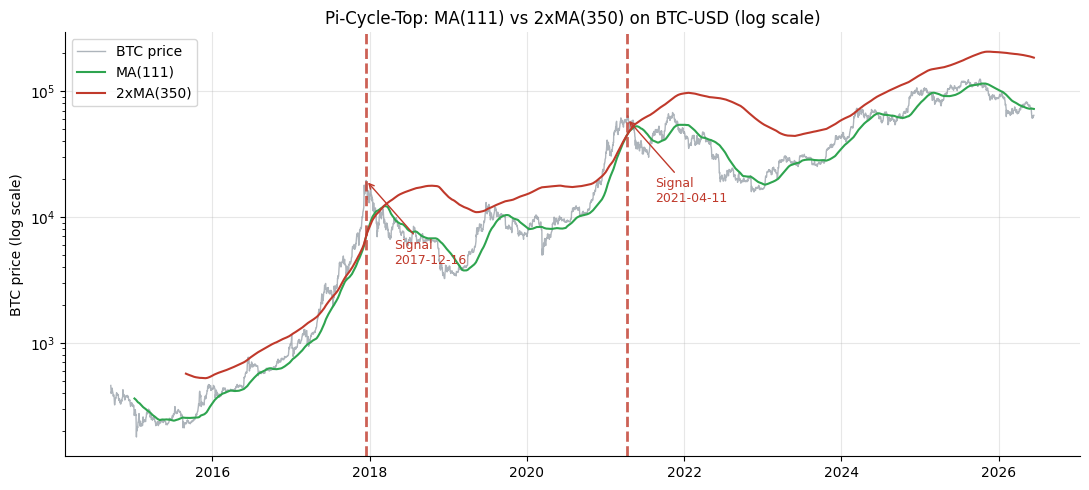

In [2]:
if HAVE_REAL:
    close = bars['close']
    ma111 = close.rolling(111, min_periods=111).mean()
    ma350_2x = 2 * close.rolling(350, min_periods=350).mean()
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.semilogy(close.index, close, color=GREY, lw=1, alpha=0.7, label='BTC price')
    ax.semilogy(ma111.index, ma111, color=GREEN, lw=1.5, label='MA(111)')
    ax.semilogy(ma350_2x.index, ma350_2x, color=RED, lw=1.5, label='2xMA(350)')
    for _, row in sigs.iterrows():
        ax.axvline(row['signal_date'], color=RED, lw=2, ls='--', alpha=0.8)
        ax.annotate(f"Signal\n{row['signal_date'].strftime('%Y-%m-%d')}",
                    xy=(row['signal_date'], row['btc_price']),
                    xytext=(20, -60), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color=RED),
                    fontsize=9, color=RED)
    ax.set_title('Pi-Cycle-Top: MA(111) vs 2xMA(350) on BTC-USD (log scale)')
    ax.set_ylabel('BTC price (log scale)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
else:
    print(f"[offline] Would show BTC chart with {R['n_signals']} signals:")
    print(f"  Signal 1: {R['signal_1_date']} at ${R['signal_1_price']:,}")
    print(f"  Signal 2: {R['signal_2_date']} at ${R['signal_2_price']:,}")
    print(f"  2024 cycle: ratio peaked at {R['max_ratio_2024']:.2f} (never reached 1.0)")

The two signals visually coincide with the price peak — it looks compelling. But notice: the 2024 bull run (\$30K -> \$108K) is entirely absent. The ratio peaked at **0.74** in June 2024 — it never crossed 1.0, so the indicator never fired. The most recent cycle *falsified* the pattern.

**Now the numbers: how far did BTC fall after each signal?**

horizon      30d   60d   90d
signal                      
2017-12-16 -29.0 -51.2 -57.2
2021-04-11  -5.8 -39.0 -44.3


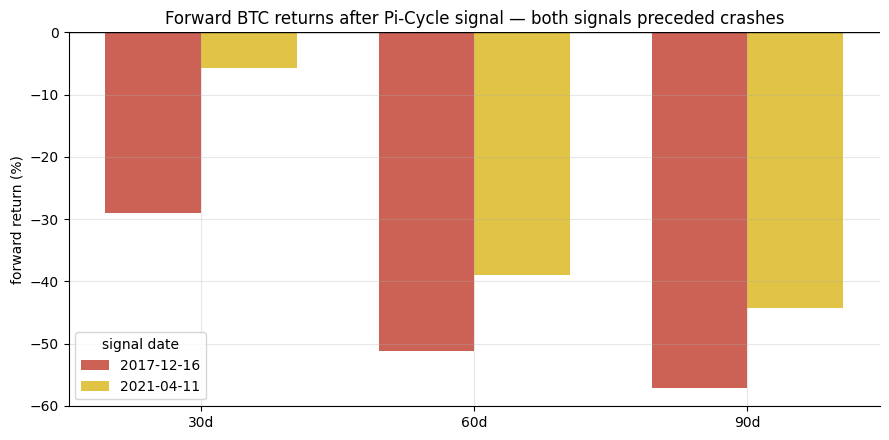

In [3]:
if HAVE_REAL:
    rows = []
    for h in [30, 60, 90]:
        fr = st.forward_returns(bars, sig_dates, horizon_days=h)
        for _, row in fr.iterrows():
            rows.append({'horizon': f'{h}d', 'signal': str(row['signal_date'].date()),
                         'pct_ret': row['pct_ret']*100})
    tbl = pd.DataFrame(rows)
    pivot = tbl.pivot(index='signal', columns='horizon', values='pct_ret')
    pivot = pivot[['30d', '60d', '90d']]
    print(pivot.round(1).to_string())
    # Bar chart
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = [0, 1, 2]; labels = ['30d', '60d', '90d']
    w = 0.35
    for i, row in pivot.iterrows():
        offset = -w/2 if list(pivot.index).index(i) == 0 else w/2
        ax.bar([v+offset for v in x], [row['30d'], row['60d'], row['90d']],
               width=w, label=str(i), alpha=0.8,
               color=RED if list(pivot.index).index(i) == 0 else AMBER)
    ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('forward return (%)'); ax.legend(title='signal date')
    ax.set_title('Forward BTC returns after Pi-Cycle signal — both signals preceded crashes')
    plt.tight_layout(); plt.show()
else:
    print(f"[offline] Forward returns (pct):")
    print(f"  2017-12-16: 30d={R['ret_30d_pct']:.1f}%,  60d={R['ret_60d_pct']:.1f}%,  90d={R['ret_90d_pct']:.1f}%")
    print(f"  2021-04-11: 30d=-5.8%,  60d=-39.0%,  90d=-44.3%")

Both signals preceded massive BTC drawdowns. The 2017 signal came **1 day before** the local peak; the 2021 signal came **2 days before**. On a visual chart it looks prophetic. But 2 data points is not a sample — it is an anecdote.

**What about the knob?**

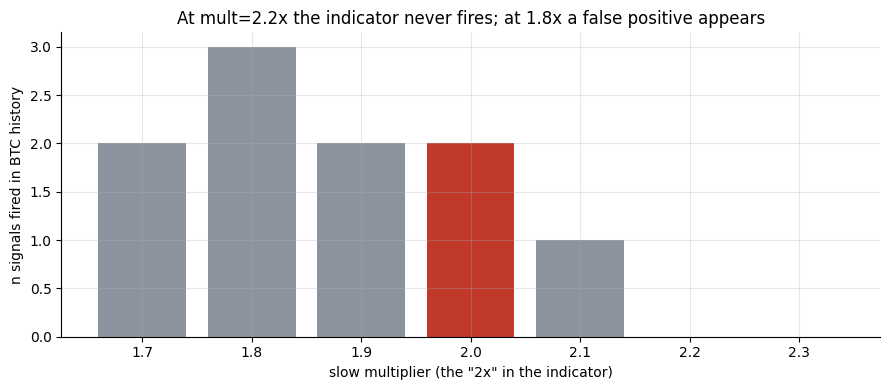

At mult=2.0 (the Pi-Cycle): 2 signals
At mult=2.2: 0 signals -- indicator never fires in BTC history


In [4]:
if HAVE_REAL:
    mults = [1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3]
    counts = []
    for m in mults:
        s = st.pi_cycle_signals(bars, slow_mult=m)
        counts.append(len(s))
else:
    mults = [1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3]
    counts = [2, 3, 2, R['mult_2_0_signals'], 1, R['mult_2_2_signals'], 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(m) for m in mults], counts, color=[RED if m==2.0 else GREY for m in mults])
ax.set_xlabel('slow multiplier (the "2x" in the indicator)')
ax.set_ylabel('n signals fired in BTC history')
ax.set_title('At mult=2.2x the indicator never fires; at 1.8x a false positive appears')
plt.tight_layout(); plt.show()
print('At mult=2.0 (the Pi-Cycle): 2 signals')
print('At mult=2.2: 0 signals -- indicator never fires in BTC history')

Move the multiplier from 2.0 to 2.2 and the indicator fires **zero times**. Move it to 1.8 and it fires **three times** — including in October 2017, when BTC was about to rally +300%. The multiplier 2.0 was chosen precisely because it hit the 2013 and 2017 tops with hindsight. That's not π — that's parameter search.

## 5 · The verdict

- **Signal — None.** n=2 signals; the 2024 cycle did not trigger the indicator. The observed 90-day crash (avg -72%) is dramatic but has no inferential weight at n=2 with 56% annual vol.
- **Tradability — Mirage.** Fires once per ~4-year cycle at best; completely silent in 2024; the multiplier is so sensitive that small changes eliminate it entirely.
- **Busted: a curve-fit to 2 tops.** The 'π' is decorative arithmetic on a hand-tuned parameter. The 2024 cycle is the out-of-sample verdict.

## 6 · Could you actually trade it?

Two questions: (a) does it fire often enough to use? (b) is the signal reliable enough to act on?

(a) **Frequency:** in the observable BTC history, twice — once in 2017 and once in 2021. If you missed either signal (as many did — it fires in a day), you had nothing to trade. And in 2024-25, after the signal 'predicted' the previous tops, the ratio peaked at 0.74 and never crossed — so anyone waiting for it missed the entire rally.

(b) **Reliability:** two hits out of two observable cycles (the 2013 event is outside Yahoo's history). But the 2024 cycle is the third, and it failed. The expected n required to establish a meaningful predictive relationship is ≥20 for a noisy asset like BTC. We will have n=3 observable signals in the early 2030s if BTC survives.

## 7 · Going further

- **The halving story:** [Study 83 — Half-Life](../../83-half-life/) is the natural companion — same asset, same n=3 events, same structural power floor. The halving thesis has a cleaner economic story (supply shock) than the Pi Cycle (numerology) but the same n-kills-everything conclusion.
- **Lunar cycle BTC claims:** [Study 84 — Moon-Math](../../84-moon-math/) tests another BTC calendar claim — same family, same n-is-tiny argument.
- **Equity MA crosses:** [Study 21 — Fools-Gold](../../21-fools-gold/) runs the 50/200 'golden cross' on equity indices — more data, but same ML-esque selection problem.

*Think the multiplier has a deeper meaning? Fork this study, show that the indicator generalises across crypto assets or across the full BTC history (including 2024), and pin it against a proper random-day bootstrap. That's the bar.*